In [1]:
!pip install numpy
!pip install pandas

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('../../data/laptop_data.csv')
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [4]:
df.shape

(1303, 12)

In [5]:
df.isnull()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,False,False,False,False,False,False,False,False,False,False,False,False
1299,False,False,False,False,False,False,False,False,False,False,False,False
1300,False,False,False,False,False,False,False,False,False,False,False,False
1301,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [8]:
df.head(2)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232


In [9]:
df['Ram'] = df['Ram'].str.replace('GB','').astype('int32')
df['Weight'] = df['Weight'].str.replace('kg','').astype('float32')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   int32  
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   float32
 11  Price             1303 non-null   float64
dtypes: float32(1), float64(2), int32(1), int64(1), object(7)
memory usage: 112.1+ KB


In [11]:
df.corr(numeric_only=True)['Price']

Unnamed: 0    0.067984
Inches        0.068197
Ram           0.743007
Weight        0.210370
Price         1.000000
Name: Price, dtype: float64

In [12]:
df['Company'].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

In [13]:
len(df['Company'].value_counts())

19

In [14]:
def add_company(inpt):
    if inpt == 'Samsung' or inpt == 'Razer' or inpt == 'Mediacom' or inpt == 'Microsoft' or inpt == 'Xiaomi' or inpt == 'Vero' or inpt == 'Chuwi' or inpt == 'Google' or inpt == 'Fujitsu' or inpt == 'LG' or inpt == 'Huawei':
        return 'Other'
    else:
        return inpt

df['Company'] = df['Company'].apply(add_company)    

In [15]:
df['Company'].value_counts()

Company
Dell       297
Lenovo     297
HP         274
Asus       158
Acer       103
MSI         54
Other       51
Toshiba     48
Apple       21
Name: count, dtype: int64

In [16]:
df['TypeName'].value_counts()

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

In [17]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
4K Ultra HD 3840x2160                              7
Touchscreen 2560x1440                              7
IPS Panel 1366x768                                 7
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x14

In [18]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
df['IPS'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [19]:
df.head(2)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0


In [20]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core M M3-6Y30 0.9GHz        1
AMD A9-Series 9420 2.9GHz          1
Intel Core i3 6006U 2.2GHz         1
AMD A6-Series 7310 2GHz            1
Intel Xeon E3-1535M v6 3.1GHz      1
Name: count, Length: 118, dtype: int64

In [21]:
len(df['Cpu'].value_counts())

118

In [22]:
df['cpu_name'] = df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))

In [23]:
df['cpu_name'].value_counts()

cpu_name
Intel Core i7               527
Intel Core i5               423
Intel Core i3               136
Intel Celeron Dual           80
Intel Pentium Quad           27
Intel Core M                 19
AMD A9-Series 9420           12
Intel Celeron Quad            8
AMD A6-Series 9220            8
AMD A12-Series 9720P          7
Intel Atom x5-Z8350           5
AMD A8-Series 7410            4
Intel Atom x5-Z8550           4
Intel Pentium Dual            3
AMD A9-Series 9410            3
AMD Ryzen 1700                3
AMD A9-Series A9-9420         2
AMD A10-Series 9620P          2
Intel Atom X5-Z8350           2
AMD E-Series E2-9000e         2
Intel Xeon E3-1535M           2
Intel Xeon E3-1505M           2
AMD E-Series 7110             2
AMD A10-Series 9600P          2
AMD A6-Series A6-9220         2
AMD A10-Series A10-9620P      2
AMD Ryzen 1600                1
Intel Atom x5-Z8300           1
AMD E-Series E2-6110          1
AMD FX 9830P                  1
AMD E-Series E2-9000          1

In [24]:
def set_processor(name):
    if name == 'Intel Core i7' or name == 'Intel Core i5' or name == 'Intel Core i3':
        return name
    else:
        if name.split()[0] == 'AMD':
            return 'AMD'
        else:
            return 'Other'

df['cpu_name'] = df['cpu_name'].apply(set_processor)

In [25]:
df['cpu_name'].value_counts()

cpu_name
Intel Core i7    527
Intel Core i5    423
Other            155
Intel Core i3    136
AMD               62
Name: count, dtype: int64

In [26]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
AMD Radeon R5 520            1
AMD Radeon R7                1
Intel HD Graphics 540        1
AMD Radeon 540               1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [27]:
len(df['Gpu'].value_counts())

110

In [28]:
df['gpu_name'] = df['Gpu'].apply(lambda x:" ".join(x.split()[0:1]))

In [29]:
df['gpu_name'].value_counts()

gpu_name
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [30]:
df.shape

(1303, 16)

In [31]:
df = df[df['gpu_name'] != 'ARM']

In [32]:
df.shape

(1302, 16)

In [33]:
df.head(2)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,cpu_name,gpu_name
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,Intel Core i5,Intel
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,Intel Core i5,Intel


In [34]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [35]:
def set_os(inpt):
    if inpt == 'Windows 10' or inpt == 'Windows 7' or inpt == 'Windows 10 S':
        return 'Windows'
    elif inpt == 'macOS' or inpt == 'Mac OS X':
        return 'Mac'
    elif inpt == 'Linux':
        return inpt
    else:
        return 'Other'

df = df.copy()
df['OpSys'] = df['OpSys'].apply(set_os)

In [36]:
df.head(12)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,cpu_name,gpu_name
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,Mac,1.37,71378.6832,0,1,Intel Core i5,Intel
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,47895.5232,0,0,Intel Core i5,Intel
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Other,1.86,30636.0000,0,0,Intel Core i5,Intel
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,Mac,1.83,135195.3360,0,1,Intel Core i7,AMD
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,Mac,1.37,96095.8080,0,1,Intel Core i5,Intel
5,5,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4,500GB HDD,AMD Radeon R5,Windows,2.10,21312.0000,0,0,AMD,AMD
6,6,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16,256GB Flash Storage,Intel Iris Pro Graphics,Mac,2.04,114017.6016,0,1,Intel Core i7,Intel
7,7,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,256GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,61735.5360,0,0,Intel Core i5,Intel
8,8,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16,512GB SSD,Nvidia GeForce MX150,Windows,1.30,79653.6000,0,0,Intel Core i7,Nvidia
9,9,Acer,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows,1.60,41025.6000,0,1,Intel Core i5,Intel


In [37]:
df['OpSys'].value_counts()

OpSys
Windows    1125
Other        94
Linux        62
Mac          21
Name: count, dtype: int64

In [38]:
df.head(2)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,cpu_name,gpu_name
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,Mac,1.37,71378.6832,0,1,Intel Core i5,Intel
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,47895.5232,0,0,Intel Core i5,Intel


In [39]:
df = df.drop(columns=['Unnamed: 0', 'Inches', 'ScreenResolution', 'Cpu', 'Gpu'])	

In [40]:
df.head()

,Company,TypeName,Ram,Memory,OpSys,Weight,Price,Touchscreen,IPS,cpu_name,gpu_name
0,Apple,Ultrabook,8,128GB SSD,Mac,1.37,71378.6832,0,1,Intel Core i5,Intel
1,Apple,Ultrabook,8,128GB Flash Storage,Mac,1.34,47895.5232,0,0,Intel Core i5,Intel
2,HP,Notebook,8,256GB SSD,Other,1.86,30636.0000,0,0,Intel Core i5,Intel
3,Apple,Ultrabook,16,512GB SSD,Mac,1.83,135195.3360,0,1,Intel Core i7,AMD
4,Apple,Ultrabook,8,256GB SSD,Mac,1.37,96095.8080,0,1,Intel Core i5,Intel


In [41]:
df['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                37
2TB HDD                           16
64GB Flash Storage                15
512GB SSD +  1TB HDD              14
1TB SSD                           14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD         

In [42]:
import re

def clean_memory(mem_str):
    mem_str = mem_str.replace('Flash Storage', 'Flash')
    mem_str = mem_str.replace('HDD', 'HDD')
    mem_str = mem_str.replace('SSD', 'SSD')
    mem_str = mem_str.replace('Hybrid', 'Hybrid')

    # Initialize sizes
    hdd = ssd = flash = hybrid = 0

    # Split by '+'
    parts = mem_str.split('+')

    for part in parts:
        part = part.strip()
        size_match = re.match(r'(\d+\.?\d*)', part)
        if size_match:
            size = float(size_match.group(1))
            if 'TB' in part:
                size *= 1024 # Convert TB to GB

            if 'HDD' in part:
                hdd += size
            elif 'SSD' in part:
                ssd += size
            elif 'Flash' in part:
                flash += size
            elif 'Hybrid' in part:
                hybrid += size

    return pd.Series([hdd, ssd, flash, hybrid])
                                    

In [43]:
df[['HDD', 'SDD', 'Flash_Storage', 'Hybrid']] = df['Memory'].apply(clean_memory)

In [44]:
df.head()

,Company,TypeName,Ram,Memory,OpSys,Weight,Price,Touchscreen,IPS,cpu_name,gpu_name,HDD,SDD,Flash_Storage,Hybrid
0,Apple,Ultrabook,8,128GB SSD,Mac,1.37,71378.6832,0,1,Intel Core i5,Intel,0.0,128.0,0.0,0.0
1,Apple,Ultrabook,8,128GB Flash Storage,Mac,1.34,47895.5232,0,0,Intel Core i5,Intel,0.0,0.0,128.0,0.0
2,HP,Notebook,8,256GB SSD,Other,1.86,30636.0000,0,0,Intel Core i5,Intel,0.0,256.0,0.0,0.0
3,Apple,Ultrabook,16,512GB SSD,Mac,1.83,135195.3360,0,1,Intel Core i7,AMD,0.0,512.0,0.0,0.0
4,Apple,Ultrabook,8,256GB SSD,Mac,1.37,96095.8080,0,1,Intel Core i5,Intel,0.0,256.0,0.0,0.0


In [45]:
df.drop('Memory', axis=1, inplace=True)

In [46]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,IPS,cpu_name,gpu_name,HDD,SDD,Flash_Storage,Hybrid
0,Apple,Ultrabook,8,Mac,1.37,71378.6832,0,1,Intel Core i5,Intel,0.0,128.0,0.0,0.0
1,Apple,Ultrabook,8,Mac,1.34,47895.5232,0,0,Intel Core i5,Intel,0.0,0.0,128.0,0.0
2,HP,Notebook,8,Other,1.86,30636.0000,0,0,Intel Core i5,Intel,0.0,256.0,0.0,0.0
3,Apple,Ultrabook,16,Mac,1.83,135195.3360,0,1,Intel Core i7,AMD,0.0,512.0,0.0,0.0
4,Apple,Ultrabook,8,Mac,1.37,96095.8080,0,1,Intel Core i5,Intel,0.0,256.0,0.0,0.0


In [47]:
df.shape

(1302, 14)

In [48]:
df = pd.get_dummies(df)

In [49]:
df.head()

,Ram,Weight,Price,Touchscreen,IPS,HDD,SDD,Flash_Storage,Hybrid,Company_Acer,...,OpSys_Other,OpSys_Windows,cpu_name_AMD,cpu_name_Intel Core i3,cpu_name_Intel Core i5,cpu_name_Intel Core i7,cpu_name_Other,gpu_name_AMD,gpu_name_Intel,gpu_name_Nvidia
0,8,1.37,71378.6832,0,1,0.0,128.0,0.0,0.0,False,...,False,False,False,False,True,False,False,False,True,False
1,8,1.34,47895.5232,0,0,0.0,0.0,128.0,0.0,False,...,False,False,False,False,True,False,False,False,True,False
2,8,1.86,30636.0000,0,0,0.0,256.0,0.0,0.0,False,...,True,False,False,False,True,False,False,False,True,False
3,16,1.83,135195.3360,0,1,0.0,512.0,0.0,0.0,False,...,False,False,False,False,False,True,False,True,False,False
4,8,1.37,96095.8080,0,1,0.0,256.0,0.0,0.0,False,...,False,False,False,False,True,False,False,False,True,False


In [50]:
df.shape

(1302, 36)

In [51]:
# Convert all bool columns to int (0 or 1)
df = df.astype({col: 'int' for col in df.select_dtypes(include='bool').columns})

In [52]:
df.dtypes

Ram                              int32
Weight                         float32
Price                          float64
Touchscreen                      int64
IPS                              int64
HDD                            float64
SDD                            float64
Flash_Storage                  float64
Hybrid                         float64
Company_Acer                     int64
Company_Apple                    int64
Company_Asus                     int64
Company_Dell                     int64
Company_HP                       int64
Company_Lenovo                   int64
Company_MSI                      int64
Company_Other                    int64
Company_Toshiba                  int64
TypeName_2 in 1 Convertible      int64
TypeName_Gaming                  int64
TypeName_Netbook                 int64
TypeName_Notebook                int64
TypeName_Ultrabook               int64
TypeName_Workstation             int64
OpSys_Linux                      int64
OpSys_Mac                

In [53]:
df.select_dtypes(include='number').head()

,Ram,Weight,Price,Touchscreen,IPS,HDD,SDD,Flash_Storage,Hybrid,Company_Acer,...,OpSys_Other,OpSys_Windows,cpu_name_AMD,cpu_name_Intel Core i3,cpu_name_Intel Core i5,cpu_name_Intel Core i7,cpu_name_Other,gpu_name_AMD,gpu_name_Intel,gpu_name_Nvidia
0,8,1.37,71378.6832,0,1,0.0,128.0,0.0,0.0,0,...,0,0,0,0,1,0,0,0,1,0
1,8,1.34,47895.5232,0,0,0.0,0.0,128.0,0.0,0,...,0,0,0,0,1,0,0,0,1,0
2,8,1.86,30636.0000,0,0,0.0,256.0,0.0,0.0,0,...,1,0,0,0,1,0,0,0,1,0
3,16,1.83,135195.3360,0,1,0.0,512.0,0.0,0.0,0,...,0,0,0,0,0,1,0,1,0,0
4,8,1.37,96095.8080,0,1,0.0,256.0,0.0,0.0,0,...,0,0,0,0,1,0,0,0,1,0


In [54]:
# Show all columns
pd.set_option('display.max_columns', None)

In [55]:
df.head()

,Ram,Weight,Price,Touchscreen,IPS,HDD,SDD,Flash_Storage,Hybrid,Company_Acer,Company_Apple,Company_Asus,Company_Dell,Company_HP,Company_Lenovo,Company_MSI,Company_Other,Company_Toshiba,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,OpSys_Linux,OpSys_Mac,OpSys_Other,OpSys_Windows,cpu_name_AMD,cpu_name_Intel Core i3,cpu_name_Intel Core i5,cpu_name_Intel Core i7,cpu_name_Other,gpu_name_AMD,gpu_name_Intel,gpu_name_Nvidia
0,8,1.37,71378.6832,0,1,0.0,128.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0
1,8,1.34,47895.5232,0,0,0.0,0.0,128.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0
2,8,1.86,30636.0000,0,0,0.0,256.0,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0
3,16,1.83,135195.3360,0,1,0.0,512.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0
4,8,1.37,96095.8080,0,1,0.0,256.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0


In [56]:
df.shape

(1302, 36)

In [57]:
X = df.drop('Price', axis=1)
Y = df['Price']

In [58]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25)

In [60]:
X_train.shape, X_test.shape

((976, 35), (326, 35))

In [62]:
def model_acc(model):
    model.fit(X_train, Y_train)
    acc = model.score(X_test, Y_test)
    print(str(model)+ ' --> ' +str(acc))

In [67]:
from sklearn.svm import SVR
svr_model = SVR(kernel = 'rbf', C=100, gamma=0.1, epsilon=0.1)
model_acc(svr_model)

SVR(C=100, gamma=0.1) --> 0.047936001302152365


In [69]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Y_train_scaled = scaler_Y.fit_transform(Y_train.values.reshape(-1, 1)).ravel()
Y_test_scaled = scaler_Y.transform(Y_test.values.reshape(-1, 1)).ravel()

In [70]:
def model_acc(model, X_train, X_test, Y_train, Y_test):
    model.fit(X_train, Y_train)
    acc = model.score(X_test, Y_test)
    print(str(model) + ' --> ' + str(acc))

In [71]:
from sklearn.svm import SVR

# Create SVR model with default or custom hyperparameters
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)

# Call the model_acc function with scaled data
model_acc(svr_model, X_train_scaled, X_test_scaled, Y_train_scaled, Y_test_scaled)

SVR(C=100, gamma=0.1) --> 0.6853135010542928


In [72]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': ['scale', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.5]
}

In [73]:
grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, Y_train_scaled)

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 10, 100, 1000], 'epsilon': [0.01, 0.1, 0.5],
                         'gamma': ['scale', 0.01, 0.1, 1]},
             scoring='r2')

In [74]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score (R²):", grid_search.best_score_)

Best Parameters: {'C': 10, 'epsilon': 0.1, 'gamma': 0.01}
Best CV Score (R²): 0.8109664508487215


In [75]:
best_model = grid_search.best_estimator_
model_acc(best_model, X_train_scaled, X_test_scaled, Y_train_scaled, Y_test_scaled)

SVR(C=10, gamma=0.01) --> 0.8043447378974062


In [78]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for SVR (valid hyperparameters)
parameters = {
    'C': [1, 10, 100],
    'gamma': [0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel': ['rbf']  # You can also try 'linear', 'poly'
}

# Create SVR model (no need to pass params yet)
svr = SVR()

# Create GridSearchCV object
grid_obj = GridSearchCV(estimator=svr, param_grid=parameters, cv=5, scoring='r2')

# Fit on scaled training data
grid_fit = grid_obj.fit(X_train_scaled, Y_train_scaled)

# Best model from grid search
best_model = grid_fit.best_estimator_

# Print best model and its score
print("Best Model:", best_model)
print("Best CV Score:", grid_fit.best_score_)

# Evaluate on test set
model_acc(best_model, X_train_scaled, X_test_scaled, Y_train_scaled, Y_test_scaled)

Best Model: SVR(C=10, gamma=0.01)
Best CV Score: 0.8109664508487215
SVR(C=10, gamma=0.01) --> 0.8043447378974062


In [79]:
import pickle

with open('predictor.pickle', 'wb') as file:
    pickle.dump(best_model, file)

In [80]:
X_train.columns

Index(['Ram', 'Weight', 'Touchscreen', 'IPS', 'HDD', 'SDD', 'Flash_Storage',
       'Hybrid', 'Company_Acer', 'Company_Apple', 'Company_Asus',
       'Company_Dell', 'Company_HP', 'Company_Lenovo', 'Company_MSI',
       'Company_Other', 'Company_Toshiba', 'TypeName_2 in 1 Convertible',
       'TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook',
       'TypeName_Ultrabook', 'TypeName_Workstation', 'OpSys_Linux',
       'OpSys_Mac', 'OpSys_Other', 'OpSys_Windows', 'cpu_name_AMD',
       'cpu_name_Intel Core i3', 'cpu_name_Intel Core i5',
       'cpu_name_Intel Core i7', 'cpu_name_Other', 'gpu_name_AMD',
       'gpu_name_Intel', 'gpu_name_Nvidia'],
      dtype='object')

In [81]:
best_model.predict([[
    8,          # Ram
    2.5,        # Weight
    1,          # Touchscreen (1 or 0)
    0,          # IPS (1 or 0)
    512,        # HDD
    0,          # SDD
    0,          # Flash_Storage
    0,          # Hybrid
    0,          # Company_Acer
    0,          # Company_Apple
    1,          # Company_Asus
    0,          # Company_Dell
    0,          # Company_HP
    0,          # Company_Lenovo
    0,          # Company_MSI
    0,          # Company_Other
    0,          # Company_Toshiba
    0,          # TypeName_2 in 1 Convertible
    0,          # TypeName_Gaming
    0,          # TypeName_Netbook
    1,          # TypeName_Notebook
    0,          # TypeName_Ultrabook
    0,          # TypeName_Workstation
    0,          # OpSys_Linux
    0,          # OpSys_Mac
    0,          # OpSys_Other
    1,          # OpSys_Windows
    0,          # cpu_name_AMD
    0,          # cpu_name_Intel Core i3
    1,          # cpu_name_Intel Core i5
    0,          # cpu_name_Intel Core i7
    0,          # cpu_name_Other
    0,          # gpu_name_AMD
    0,          # gpu_name_Intel
    1           # gpu_name_Nvidia
]])

array([1.20424811])

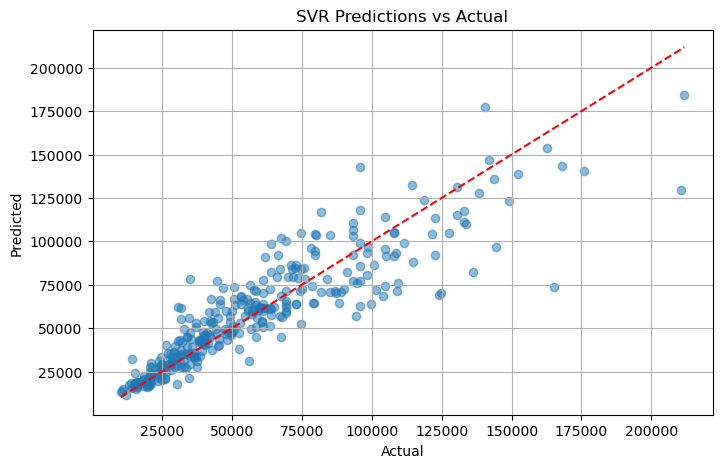

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Predict and inverse transform
Y_pred_scaled = best_model.predict(X_test_scaled)
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled.reshape(-1, 1))
Y_actual = scaler_Y.inverse_transform(Y_test_scaled.reshape(-1, 1))

# Plot
plt.figure(figsize=(8,5))
plt.scatter(Y_actual, Y_pred, alpha=0.5)
plt.plot([Y_actual.min(), Y_actual.max()], [Y_actual.min(), Y_actual.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('SVR Predictions vs Actual')
plt.grid(True)
plt.show()